In [ ]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report

df = pd.read_csv('/home/sm3sh4r1c/Рабочий стол/MLhomeworks/archive/WineQT.csv')

### 1. Первичный анализ

In [37]:
print(f'==========\nРазмер датасета:\n{df.shape}\n==========')
print(f'Первые 5 строк:\n{df.head()}\n==========')
print(f'Типы признаков:\n{df.dtypes}\n==========')

Размер датасета:
(1143, 13)
Первые 5 строк:
   fixed acidity  volatile acidity  citric acid  ...  alcohol  quality  Id
0            7.4              0.70         0.00  ...      9.4        5   0
1            7.8              0.88         0.00  ...      9.8        5   1
2            7.8              0.76         0.04  ...      9.8        5   2
3           11.2              0.28         0.56  ...      9.8        6   3
4            7.4              0.70         0.00  ...      9.4        5   4

[5 rows x 13 columns]
Типы признаков:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object


df.shape - нужна, чтобы показать сколько строк и сколько признаков

df.head - показывает первые пять строк датасета

df.dtypes - показывает тип признаков

P.S.:   из нашего опыта следует что все признаки числовые 

In [14]:
miss_u = df.isnull().sum()

for i in miss_u:
    if i == 1:
        print(f"{miss_u[i]}\t пропуска есть")
        break
    else:
        continue    
print("пропусков нет")


пропусков нет


сделал цикл который чекает датасет на пропуски, если = 1 - пропуски есть, иначе пропусков. Из опыта следует пропусков нет, значит заменять пропуски не имеет смысла

In [15]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


.describe() - показывает статистики по датасету среди числовых признаков

In [38]:
df['quality'].value_counts().sort_index()

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

Распределения классов - показывает оценку по определенному признаку

Оценка 5 больше оценки 8 --> датасет может плохо научиться распознавать плохие случаи

### 2. Подготовка данных

In [60]:
df['quality_binary'] = (df['quality'] >= 6).astype(int)

X = df.drop(['quality', 'quality_binary'], axis=1)
y = df['quality_binary']

print(f'распред после бинаризации:\n{y.value_counts()}\n')
print(f'Доля хороших вин:\t {y.mean():.2%}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42
    )

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

распред после бинаризации:
quality_binary
1    621
0    522
Name: count, dtype: int64

Доля хороших вин:	 54.33%


Здесь проводится разделение на признаки бинарн. и целевую переменную 'quality'. сделал бинарную классификацию для простого сравнения 1 - хорошее и 0 - плохое.

Далее сделал разделение на train/test

1. Почему масштабирование важно для KNN?

    В датасете Wine Quality есть признаки с разными единицами измерения. Без масштабирования признак с большими значениями будет доминировать при расчете расстояния.
    Масштабирование приводит все признаки к общему масштабу, делая их вклад равноправным.

2. Почему нельзя подбирать параметры на тестовой выборке?

    Если мы будем использовать её для настройки произойдет утечка данных и мы не сможем объективно оценить её качество

### 3. Обучение KNN-модели

In [51]:
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_scaled, y_train)
y_pred_best = knn_base.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test,y_pred_best)
test_f1_m = f1_score(y_test,y_pred_best, average='macro')
test_f1_w = f1_score(y_test,y_pred_best, average='weighted')
test_prec_m = precision_score(y_test,y_pred_best,average='macro')
test_prec_w = precision_score(y_test,y_pred_best,average='weighted')
test_recall_m = recall_score(y_test, y_pred_best,average='macro')
test_recall_w = recall_score(y_test, y_pred_best,average='weighted')


print(f'accuracy:\t{test_accuracy:.4f}\n')
print(f'f1_m:\t\t{test_f1_m:.4f}')
print(f'precision_m:\t{test_prec_m:.4f}')
print(f'recall_m:\t{test_recall_m:.4f}\n')
print(f'f1_w:\t\t{test_f1_w:.4f}')
print(f'precision_w:\t{test_prec_w:.4f}')
print(f'recall_w:\t{test_recall_w:.4f}')

print(classification_report(y_test,y_pred_best))

accuracy:	0.5590

f1_m:		0.2965
precision_m:	0.2993
recall_m:	0.2967

f1_w:		0.5473
precision_w:	0.5380
recall_w:	0.5590
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.63      0.67      0.65        96
           6       0.55      0.59      0.57        99
           7       0.32      0.23      0.27        26
           8       0.00      0.00      0.00         2

    accuracy                           0.56       229
   macro avg       0.30      0.30      0.30       229
weighted avg       0.54      0.56      0.55       229



/home/sm3sh4r1c/Рабочий стол/MLhomeworks/MLhomeworks/ml-course-homeworks/.myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sm3sh4r1c/Рабочий стол/MLhomeworks/MLhomeworks/ml-course-homeworks/.myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sm3sh4r1c/Рабочий стол/MLhomeworks/MLhomeworks/ml-course-homeworks/.myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 

Провел обучение knn-модели, а также сразу провел оценки модели такие как accuracy, f1, precision, recall. Заметил, что для последних трех оценок нужно также прописать такой параметр average он может быть None, macro, weighted. На всякий пожарный прописал только macro и weighted. Classification_report - нужна чтобы не писать каждый раз оценку тестовой выборки.

### 4. Исследование параметров KNN

In [63]:
k_values= [3,5,7,9,11,13,15]
weights = ['uniform','distance']
metrics = ['euclidean','manhattan','minkowski']

results = []
for k in k_values:
    for w in weights:
        for m in metrics:
            knn = KNeighborsClassifier(n_neighbors=k,weights=w,metric=m)
            knn.fit(X_train_scaled, y_train)
            y_pred = knn.predict(X_test_scaled)
            acc = accuracy_score(y_test, y_pred)
            f1_macro = f1_score(y_test,y_pred,average='macro')
            f1_weighted = f1_score(y_test, y_pred, average='weighted')
            results.append({
                'k':k,
                'weights':w,
                'metric':m,
                'accuracy':acc,
                'f1_macro':f1_macro,
                'f1_weighted':f1_weighted
            })

results_df = pd.DataFrame(results)



### 5. Подбор гиперпараметров

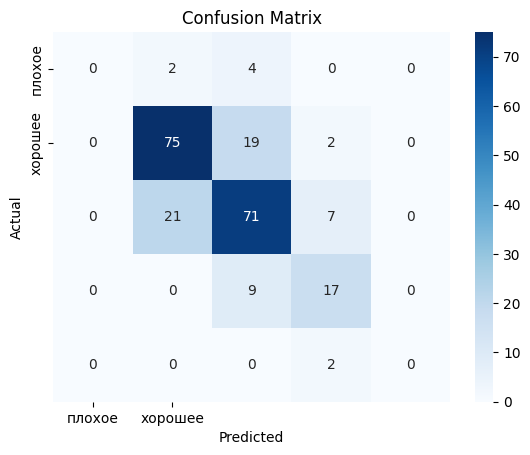

In [56]:
param_grid = {
    'n_neighbors':[3,5,7,9,11,13,15],
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan','minkowski']
}

knn_base = KNeighborsClassifier()
grid_search = GridSearchCV(knn_base,param_grid,cv=5,scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled,y_train)

best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred_best)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['плохое','хорошее'],yticklabels=['плохое','хорошее'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()